In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
import scipy.constants as constants
import tables

In [2]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

In [3]:
dim = 8
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

numSubPixels = 128

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
# sim["SubField/SubPixels"] = numSubPixels

sim["PSF/Model"] = "AnalyticNonGaussian"

sim["Sky/SkyBackground"] = 0
magnitude = 12.5

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

In [4]:
positions = np.arange(dim, 4600, 100)
offset = 0.5

encircledEnergyFraction2by2_sim = np.array([])
encircledEnergyFraction4by4_sim = np.array([])
encircledEnergyFraction6by6_sim = np.array([])

for position in positions:
    
    sim["SubField/ZeroPointRow"] = position - dim // 2
    sim["SubField/ZeroPointColumn"] = position - dim // 2
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position + offset]), np.array([position + offset]), np.array([magnitude]), np.array([1]), starCatalogFilename)
    
    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)

    startIndex = int(dim / 2) - 1
    endIndex = startIndex + 2
    energy2by2 = np.sum(image[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 2
    endIndex = startIndex + 4
    energy4by4 = np.sum(image[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 3
    endIndex = startIndex + 6
    energy6by6 = np.sum(image[startIndex:endIndex, startIndex:endIndex])
    
    encircledEnergyFraction2by2_sim = np.append(encircledEnergyFraction2by2_sim, energy2by2)
    encircledEnergyFraction4by4_sim = np.append(encircledEnergyFraction4by4_sim, energy4by4)
    encircledEnergyFraction6by6_sim = np.append(encircledEnergyFraction6by6_sim, energy6by6)

In [5]:
# Convert the magnitude to flux (for the total flux)

fluxm0 = sim["ObservingParameters/Fluxm0"]
throughputBandWidth = sim["Camera/ThroughputBandwidth"]
transmissionEfficiency = sim["Telescope/TransmissionEfficiency/BOL"]
lightCollectingArea = sim["Telescope/LightCollectingArea"] * 1e-4

fluxFactor = fluxm0 * throughputBandWidth * transmissionEfficiency * lightCollectingArea

timeStep = sim["ObservingParameters/CycleTime"] - sim.getReadoutTime()[0]  # Exposure time [s]

totalFlux =  math.floor(fluxFactor * pow(10.0, -0.4 * magnitude) * timeStep)

In [6]:
plateScaleArcsec = 15
distances = positions * plateScaleArcsec / constants.degree * constants.arcsec

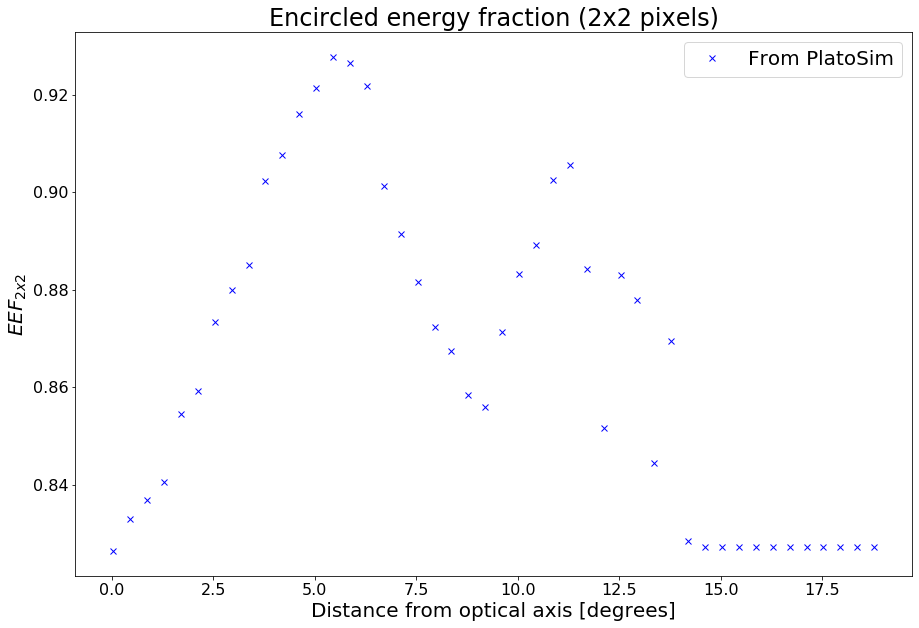

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction2by2_sim / totalFlux, "bx", label = "From PlatoSim")

########
# Layout
########

plt.title("Encircled energy fraction (2x2 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{2x2}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

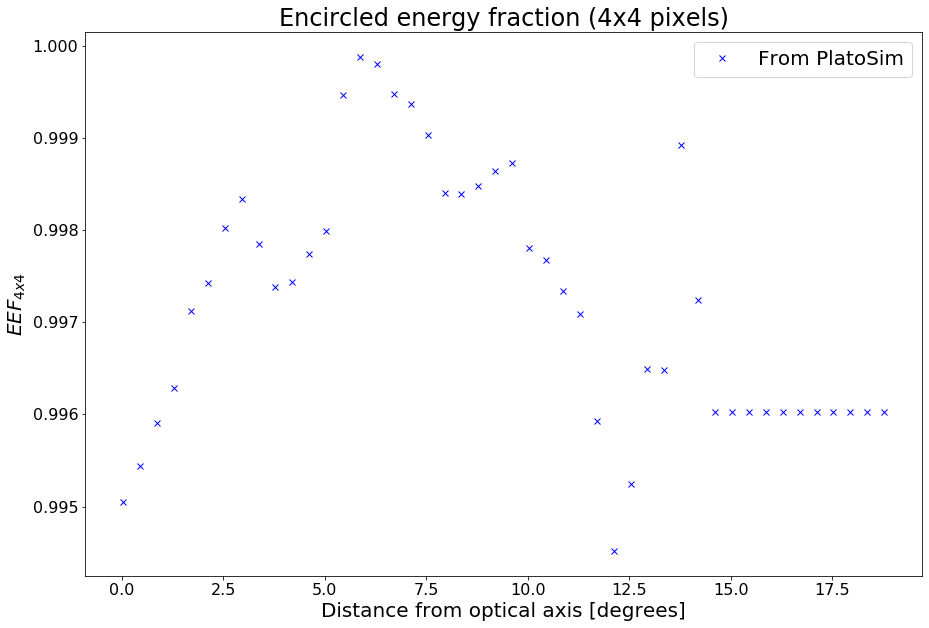

In [8]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction4by4_sim / totalFlux, "bx", label = "From PlatoSim")

########
# Layout
########

plt.title("Encircled energy fraction (4x4 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{4x4}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

(0.9999, 1.00001)

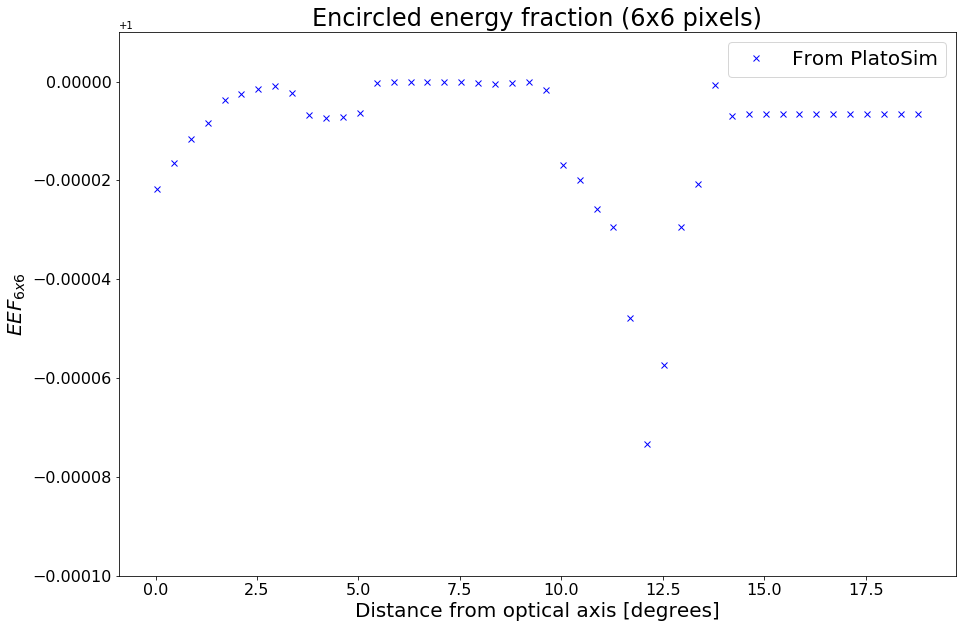

In [9]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction6by6_sim / totalFlux, "bx", label = "From PlatoSim")

########
# Layout
########

plt.title("Encircled energy fraction (6x6 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{6x6}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])
plt.ylim([0.9999, 1.00001])

In [10]:
distances = np.array([0, 1414, 2827, 4238, 5647, 7053, 8454, 9850, 11241, 12625, 14001, 15370, 16730, 18081, 18887])

distances = distances / 1000

In [11]:
filename = os.environ["PLATO_PROJECT_HOME"] + "/" + sim["PSF/MappedFromFileSymmetrical/Filename"]
psfFile = tables.open_file(filename)
children = psfFile.root.T6000

dim = 1024
numSubPixels = 128
encircledEnergyFraction = np.array([])
encircledEnergyFraction2by2 = np.array([])
encircledEnergyFraction4by4 = np.array([])
encircledEnergyFraction6by6 = np.array([])

index = 0

for child in children:
    
    psf = np.array(child.az0)
    
    startIndex = int(dim / 2) - 1 * numSubPixels
    endIndex = startIndex + 2 * numSubPixels
    energy2by2 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 2 * numSubPixels
    endIndex = startIndex + 4 * numSubPixels
    energy4by4 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 3 * numSubPixels
    endIndex = startIndex + 6 * numSubPixels
    energy6by6 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    encircledEnergyFraction = np.append(encircledEnergyFraction, energy4by4)
    encircledEnergyFraction2by2 = np.append(encircledEnergyFraction2by2, energy2by2)
    encircledEnergyFraction4by4 = np.append(encircledEnergyFraction4by4, energy4by4)
    encircledEnergyFraction6by6 = np.append(encircledEnergyFraction6by6, energy6by6)
    
    index += 1
    
    print(child)

/T6000/ar00000 (Group) ''
/T6000/ar01414 (Group) ''
/T6000/ar02827 (Group) ''
/T6000/ar04238 (Group) ''
/T6000/ar05647 (Group) ''
/T6000/ar07053 (Group) ''
/T6000/ar08454 (Group) ''
/T6000/ar09850 (Group) ''
/T6000/ar11241 (Group) ''
/T6000/ar12625 (Group) ''
/T6000/ar14001 (Group) ''
/T6000/ar15370 (Group) ''
/T6000/ar16730 (Group) ''
/T6000/ar18081 (Group) ''
/T6000/ar18887 (Group) ''


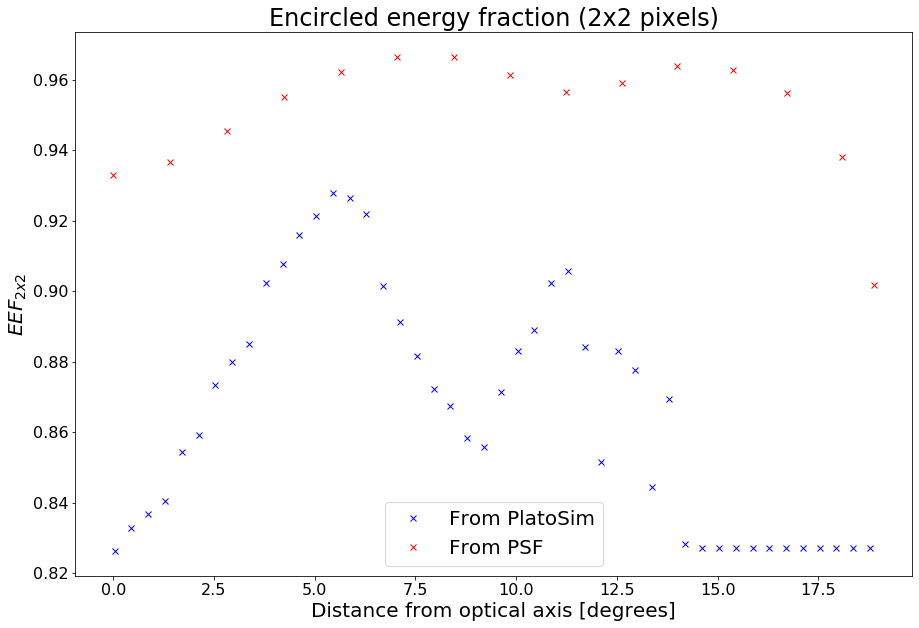

In [12]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction2by2_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction2by2, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (2x2 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{2x2}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

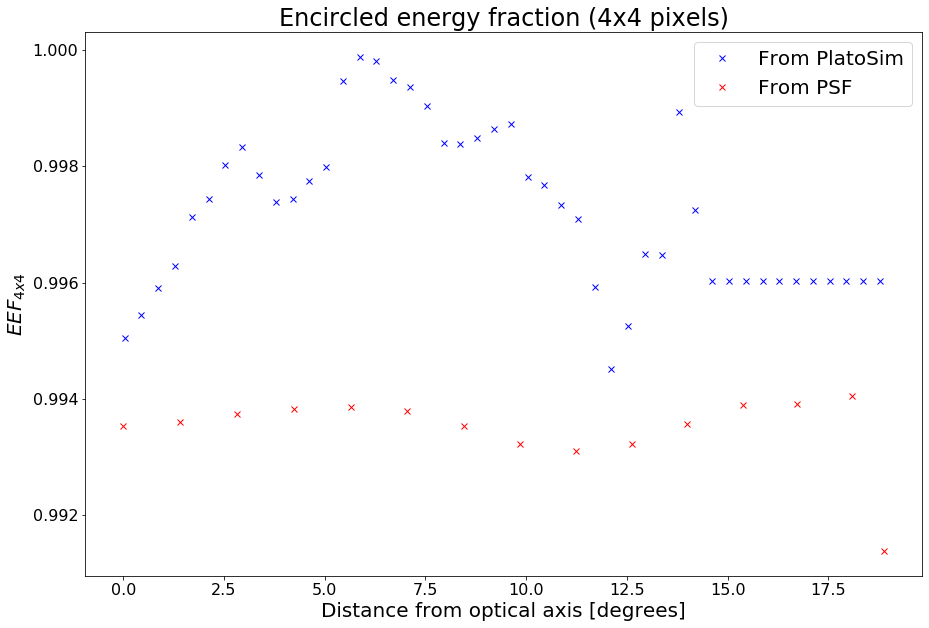

In [13]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction4by4_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction4by4, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (4x4 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{4x4}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

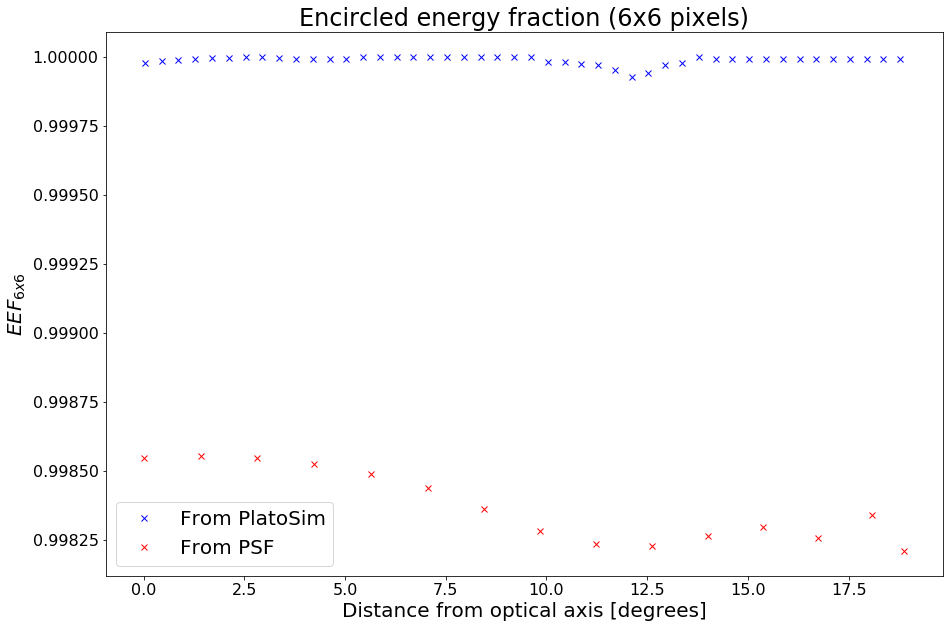

In [14]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction6by6_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction6by6, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (6x6 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{6x6}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

In [15]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 20
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

In [16]:
sim["PSF/Model"] = "AnalyticNonGaussian"
sigma = sim["PSF/AnalyticNonGaussian/Sigma/ConstantValue"]

In [17]:
positions = np.arange(200, 4700, 100)
offset = 0.5

fittedSigmaPixel = np.array([])
fittedSigmaSubPixel = np.array([])

for position in positions:
    
    print(position)
    
    sim["SubField/ZeroPointRow"] = position - dim // 2
    sim["SubField/ZeroPointColumn"] = position - dim // 2
        
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position + offset]), np.array([position + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    
    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
#     sigma = math.sqrt(2 * ((position + 0.5)**2)) / 1000.0 * 1.5
#     print(sigma)
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    print(params[3])

200


0.4530817980877639
300


0.44795758559864757
400


0.4374629388494666
500


0.4363121658513518
600


0.42822070261049444
700


0.4252121555887978
800


0.42325684343175085
900


0.4153861924146999
1000


0.4136335305953345
1100


0.4156272382032332
1200


0.4158888430221985
1300


0.42290268963469024
1400


0.42961606635948596
1500


0.4332409370143009
1600


0.44590842695293464
1700


0.4523004664541263
1800


0.4585882050788753
1900


0.46324373242123384
2000


0.4624372952686558
2100


0.4631241662283492
2200


0.4662816285082662
2300


0.4614712585165305
2400


0.45730312069069823
2500


0.4516990749531625
2600


0.4398021853849675
2700


0.4351072819251263
2800


0.4223468746830649
2900


0.4261981397952682
3000


0.4236143055522599
3100


0.4344227100798201
3200


0.4521912066208994
3300


0.4634387892954026
3400


0.5203445895114085
3500


0.5314584495253762
3600


0.5314584495253762
3700


0.5314584495253762
3800


0.5314584495253762
3900


0.5314584495253762
4000


0.531

In [18]:
plateScaleArcsec = 15
distances = positions * plateScaleArcsec / constants.degree * constants.arcsec # [pixels]

(0, 18.8908)

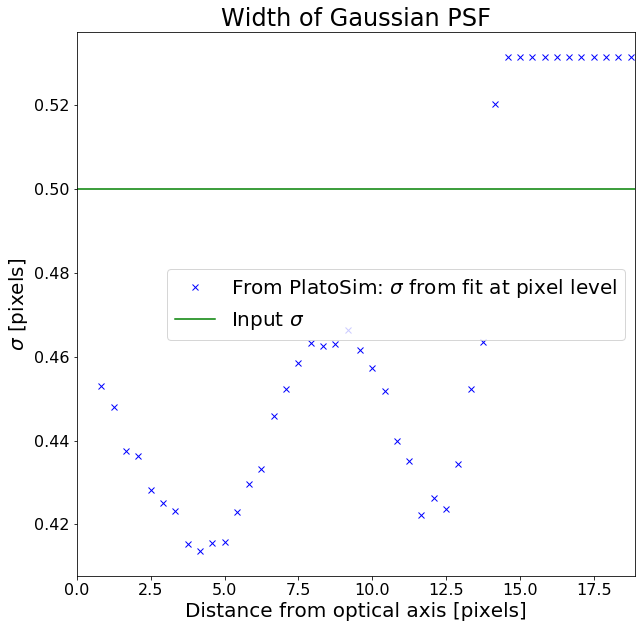

In [19]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")

########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Distance from optical axis [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
plt.xlim([0, fovDegrees])

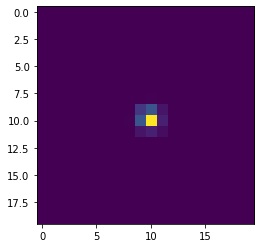

In [20]:
plt.imshow(output.getImage(0))